In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


PROJECT_ROOT = Path.cwd()

# Handles running the notebook either from the project root
# or from inside the notebooks folder.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "final_model_dataset.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["Date"],
)

df.head()

,Ticker,Date,adj_close,monthly_return,mom_1m,mom_3m,mom_6m,mom_12m,vol_3m,vol_6m,...,DGS10,DGS2,DFF,VIXCLS,yield_spread_10y_2y,DGS10_change_1m,DGS2_change_1m,DFF_change_1m,VIXCLS_change_1m,yield_spread_10y_2y_change_1m
0,XLB,2016-01-31,15.670033,-0.107094,-0.107094,-0.137358,-0.145207,-0.169502,0.202969,0.298163,...,1.94,0.76,0.29,20.2,1.18,-0.33,-0.3,0.09,1.99,-0.03
1,XLE,2016-01-31,19.013155,-0.034980,-0.034980,-0.136598,-0.147153,-0.206244,0.185308,0.260644,...,1.94,0.76,0.29,20.2,1.18,-0.33,-0.3,0.09,1.99,-0.03
2,XLF,2016-01-31,14.469118,-0.088544,-0.088544,-0.092355,-0.128799,-0.037752,0.189094,0.194456,...,1.94,0.76,0.29,20.2,1.18,-0.33,-0.3,0.09,1.99,-0.03
3,XLI,2016-01-31,41.532219,-0.056970,-0.056970,-0.073272,-0.067406,-0.064508,0.113719,0.186218,...,1.94,0.76,0.29,20.2,1.18,-0.33,-0.3,0.09,1.99,-0.03
4,XLK,2016-01-31,18.357542,-0.037124,-0.037124,-0.050466,-0.022216,0.052444,0.077473,0.196560,...,1.94,0.76,0.29,20.2,1.18,-0.33,-0.3,0.09,1.99,-0.03


In [3]:
print("Shape:", df.shape)
print()
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print()
print("Tickers:", sorted(df["Ticker"].unique()))
print()
print("Number of ETFs:", df["Ticker"].nunique())

Shape: (1181, 42)

Date range: 2016-01-31 00:00:00 to 2025-11-30 00:00:00

Tickers: ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']

Number of ETFs: 10


In [4]:
print(
    "Duplicate ETF-month rows:",
    df.duplicated(subset=["Date", "Ticker"]).sum(),
)

print(
    "Total missing values:",
    df.isna().sum().sum(),
)

print(
    "Target values:",
    sorted(df["target"].unique()),
)

Duplicate ETF-month rows: 0
Total missing values: 0
Target values: [np.int64(0), np.int64(1)]


In [5]:
df.groupby("Ticker").size().sort_values(ascending=False)

Ticker
XLB     119
XLE     119
XLF     119
XLI     119
XLK     119
XLP     119
XLU     119
XLV     119
XLY     119
XLRE    110
dtype: int64

In [6]:
target_counts = df["target"].value_counts().sort_index()
target_rates = df["target"].value_counts(normalize=True).sort_index()

print("Counts:")
print(target_counts)

print()
print("Proportions:")
print(target_rates)

Counts:
target
0    638
1    543
Name: count, dtype: int64

Proportions:
target
0    0.54022
1    0.45978
Name: proportion, dtype: float64


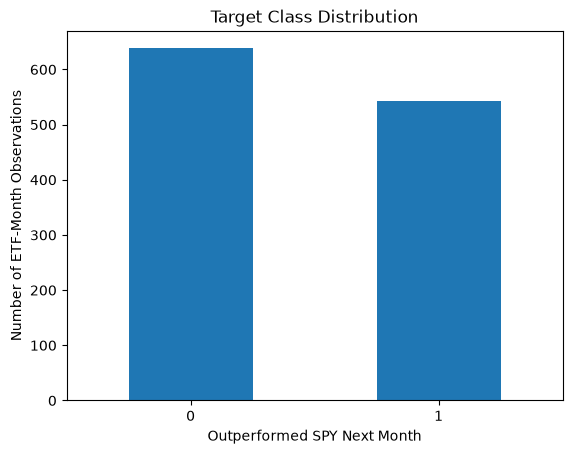

In [7]:
target_counts.plot(kind="bar")

plt.title("Target Class Distribution")
plt.xlabel("Outperformed SPY Next Month")
plt.ylabel("Number of ETF-Month Observations")
plt.xticks(rotation=0)
plt.show()

In [8]:
target_by_year = (
    df.assign(Year=df["Date"].dt.year)
    .groupby("Year")["target"]
    .mean()
)

target_by_year

Year
2016    0.495495
2017    0.450000
2018    0.458333
2019    0.425000
2020    0.450000
2021    0.475000
2022    0.583333
2023    0.358333
2024    0.441667
2025    0.463636
Name: target, dtype: float64

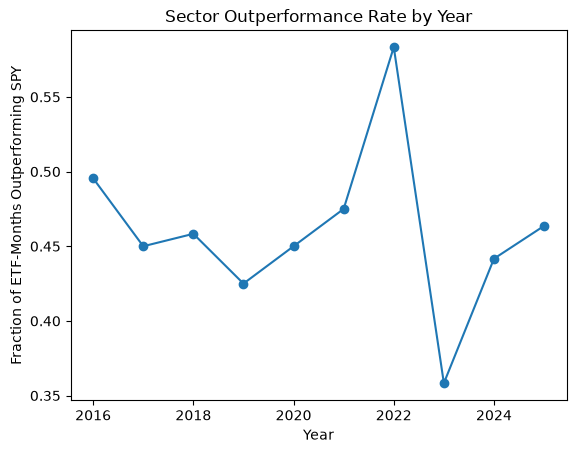

In [9]:
target_by_year.plot(marker="o")

plt.title("Sector Outperformance Rate by Year")
plt.xlabel("Year")
plt.ylabel("Fraction of ETF-Months Outperforming SPY")
plt.show()

In [10]:
exclude_columns = [
    "target",
    "adj_close",
    "monthly_return",
    "next_etf_return",
    "next_spy_return",
]

numeric_columns = (
    df.select_dtypes(include="number")
    .columns
    .difference(exclude_columns)
)

target_correlations = (
    df[numeric_columns]
    .corrwith(df["target"])
    .sort_values()
)

target_correlations

spy_drawdown_12m                -0.046757
drawdown_12m                    -0.044925
DFF                             -0.044533
mom_3m                          -0.044304
spy_monthly_return              -0.032449
spy_mom_1m                      -0.032449
relative_mom_3m                 -0.031420
spy_mom_12m                     -0.030163
spy_mom_3m                      -0.026074
yield_spread_10y_2y_change_1m   -0.025338
mom_12m                         -0.025198
DGS2                            -0.022638
mom_1m                          -0.020289
DGS10                           -0.016028
mom_6m                          -0.015141
spy_mom_6m                      -0.012465
relative_drawdown_12m           -0.012040
relative_mom_6m                 -0.007078
relative_mom_12m                -0.002851
DGS10_change_1m                 -0.002266
relative_vol_6m                  0.005761
relative_mom_1m                  0.008090
spy_vol_12m                      0.011174
DGS2_change_1m                   0

In [11]:
top_correlations = (
    target_correlations
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

top_correlations

vol_3m                0.065685
DFF_change_1m         0.053302
spy_drawdown_12m      0.046757
relative_vol_3m       0.046533
VIXCLS                0.045184
drawdown_12m          0.044925
DFF                   0.044533
mom_3m                0.044304
VIXCLS_change_1m      0.042641
spy_vol_3m            0.038116
spy_vol_6m            0.034467
spy_mom_1m            0.032449
spy_monthly_return    0.032449
vol_12m               0.031901
relative_mom_3m       0.031420
dtype: float64